### ANN for regression, example 3, diamond sales data (+ how to handle ordinal variables)

#### Imports / modules

In [7]:
# pip install scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import metrics

# pip install tensorflow
import tensorflow as tf
import keras
from keras import layers

#### Loading the dataset

In [8]:
# load the data
df = pd.read_csv("diamonds.csv")

# drop the extra Unnamed -column
df = df.drop("Unnamed: 0", axis=1)

In [ ]:
# this is a pretty sizeable dataset!
len(df)

53940

<Axes: >

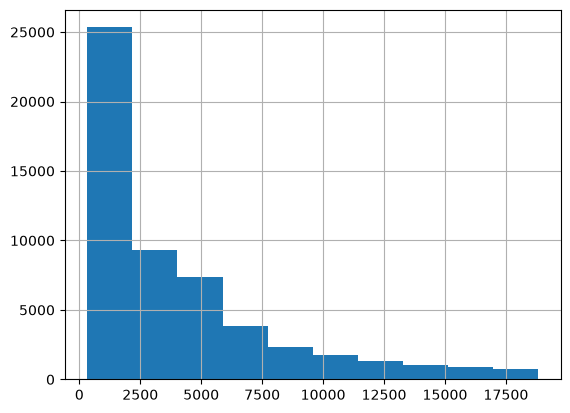

In [ ]:
# most diamonds are cheaper ones
df['price'].hist()

In [11]:
# quickly check the first few rows of data
# to see what we have here
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


### Few more checks for data, any missing values or duplicates

In [12]:
# it seems we don't have any missing values
df.isna().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [13]:
# it seems we have some duplicates, probably good to remove these
int(df.duplicated().sum())

146

In [14]:
# drop the duplicates
df = df.drop_duplicates()

In [15]:
# sanity check, are the duplicates gone now?
int(df.duplicated().sum())

0

### Handling the categorical variables

*Type 1: Boolean categories*

In [16]:
# this dataset doesn't have any binary categories

*Type 2: Ordinal categories*

In [ ]:
# ordinal category = text category where the options have an order
# of magnitude between the options (comparable numerically)

# apparently using replace in this context is deprecated approach
# for future reasons, probably better use the map-function

# this example is from Moodle:

# # our dataset in this example
# df = sns.load_dataset("diamonds")

# # most practical way to do this operation is to use a dictionary
# # and replace the values with numeric values with .map()

# # you can define the magnitude order within this dictionary
# # in this dataset, the scale is from Fair – Ideal 
# # typical case is something like Low: 0, Average: 1, High: 2
cut_mapper = {'Fair': 1, 'Good': 2,'Very Good': 3, 'Premium': 4, 'Ideal': 5}
df['cut'] = df['cut'].map(cut_mapper)

# even if it feels "wrong", diamond color is an ordinal category, see this:
# https://cldnr.rarecarat.com/image/upload/v1755207799/cms/diamond_Color_Chart1_9020e7ec7b.png
color_mapper = {'J': 1, "I": 2, "H": 3, "G": 4, "F": 5, "E": 6, "D": 7}
df['color'] = df['color'].map(color_mapper)

# clarity is also ordinal, see this:
# https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSnlWPlEvMnTIKFYe8lYLsL2hqYBry8Oj80YSBt5oOmwoB4ThJlBXOUw5k&s=10
clarity_mapper = {'I1': 1, "SI2": 2, "SI1": 3, "VS2": 4, "VS1": 5, "VVS2": 6, "VVS1": 7, "IF": 8}
df['clarity'] = df['clarity'].map(clarity_mapper)

*Type 3: Nominal categories*

In [18]:
# no nominal categories in this dataset

In [19]:
# small check, are all values numericn now?
df

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,5,6,2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,4,6,3,59.8,61.0,326,3.89,3.84,2.31
2,0.23,2,6,5,56.9,65.0,327,4.05,4.07,2.31
3,0.29,4,2,4,62.4,58.0,334,4.20,4.23,2.63
4,0.31,2,1,2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,5,7,3,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,2,7,3,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,3,7,3,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,4,3,2,61.0,58.0,2757,6.15,6.12,3.74


#### X/y -split

In [20]:
# perform X/y -split
# if you more than one independent variable, list them all here
# leave out the target variable (dependent variable)

# this is a nice and common trick => everything EXCEPT the target variable => support variables
X = df.drop("price", axis=1)

# have only the target variable here (dependent variable)
y = df['price']

#### Train/test/validation -split

In [21]:
# in Classic ML, we only had train/test -split
# in deep learning, we usually use validation-data also, for better
# optimization possibilities and better metrics

# unfortunately the scikit-learn's train_test_split doesn't support validation
# set split in itself.

# if you want to split the test set into two for a validation set too, try this trick:

# step 1, split the data into 70% (training data) and 30% (temporary data)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3)

# step 2, split the temporary data in HALF (0.5) => 15% test and 15% validation
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5)

#### Create a neural network structure

In [22]:
# create neural network

# save the amount of support variables into a helper variable
# so we don't have to update the input_shape all the time
variable_amount = len(X.columns)

# Define Sequential neural network model
# input shape has to match the amount of SUPPORT VARIABLES
# in other words => amount of columns in X 
# Tip: have at least the same number of nodes as in the input shape
# output layer in regression is always 1 node without activation function
model = keras.Sequential(
    [
        layers.Dense(16, activation="relu", input_shape=(variable_amount,)),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1)
    ]
)

# select the optimizer and loss function
# you can try rmsprop also as optimizer, or stochastic gradient descent
# loss-function for regression is mse (mean squared error)
model.compile(optimizer='adam', loss='mse')

model.summary()

c:\Users\tuomas.valtanen\deeplearning2026lectures\DeepLearningAutumn2026\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,249 (4.88 KB)

 Trainable params: 1,249 (4.88 KB)

 Non-trainable params: 0 (0.00 B)

#### Train the neural network

In [23]:
# train/fit neural network with validation data
# see the instructions on the train/test -split above on how to split the data correctly
model.fit(x=X_train, y=y_train, epochs=800, validation_data=(X_val, y_val))

Epoch 1/800
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 2s 997us/step - loss: 17265274.0000 - val_loss: 14820085.0000
Epoch 2/800
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 1s 869us/step - loss: 13254933.0000 - val_loss: 10532036.0000
Epoch 3/800
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 1s 890us/step - loss: 4956743.5000 - val_loss: 2734038.7500
Epoch 4/800
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 1s 875us/step - loss: 1752031.5000 - val_loss: 1648030.0000
Epoch 5/800
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 1s 883us/step - loss: 1138554.3750 - val_loss: 1442909.3750
Epoch 6/800
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 1s 864us/step - loss: 974105.0625 - val_loss: 1319783.5000
Epoch 7/800
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 1s 875us/step - loss: 901210.5625 - val_loss: 1276276.1250
Epoch 8/800
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 1s 880us/step - loss: 872291.0000 - val_loss: 1263632.2500
Epoch 9/800
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 1s 858us/step - loss: 852525.5625 - val_loss: 1245437.5000
Epoch 10/800
1177/1177 ━━━━━━━━━━━━━━━━━━━━ 1s 873us/step - loss: 844074.

#### Training metrics in order to see if the model trained an works well

<Axes: >

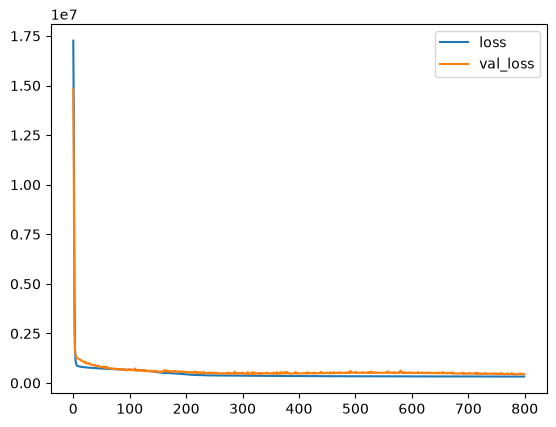

In [24]:
# let's use pandas for this (easy code)
# try to look if the model is actually training 
# => the error is going downwards
# if using validation data, you get two lines
# in this case, see if the lines follow a similar trend 
# (they don't always overlap with complex data, the trend is more important)
loss_df = pd.DataFrame(model.history.history)
loss_df.plot()

In [25]:
# compare the final model loss/evaluation values
print("Test data evaluation:")
print(model.evaluate(X_test, y_test, verbose=0))
print("\nTrain data evaluation:")
print(model.evaluate(X_train, y_train, verbose=0))

Test data evaluation:
332188.59375

Train data evaluation:
314795.90625


#### Error metrics

In [26]:
# get test predictions
test_predictions = model.predict(X_test)

# reshape the data for easier comparison table
test_predictions = pd.Series(test_predictions.reshape(len(y_test),))
pred_df = pd.DataFrame(np.asarray(y_test), columns=['Test True Y'])
pred_df = pd.concat([pred_df, test_predictions], axis=1)
pred_df.columns = ['Test True Y', 'Model Predictions']

# print the comparison table - true values vs. model predicted values
# we can nicely see here how far off our model is in some cases
pred_df

253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 501us/step


,Test True Y,Model Predictions
0,972,809.953552
1,2618,2264.013672
2,10011,3977.706299
3,3425,3458.834229
4,1215,1277.656372
...,...,...
8065,2993,3143.815674
8066,12186,12604.632812
8067,6458,7289.961426
8068,828,710.157898


<Axes: xlabel='Test True Y', ylabel='Model Predictions'>

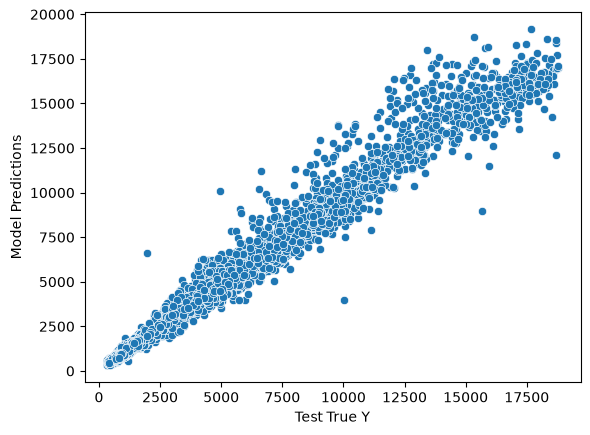

In [27]:
# these values follow a linear diagonal line = good predictions
# we basically compare the predicted values 
# to true test values and see the differences
sns.scatterplot(x='Test True Y', y='Model Predictions', data=pred_df)

In [28]:
# MAE - Mean average error
print("MAE")
print(round(metrics.mean_absolute_error(y_test, test_predictions), 2), "$")

# MSE - Mean square error
print("\nMSE")
print(round(metrics.mean_squared_error(y_test, test_predictions), 2), "$^2")

# RMSE - Root mean square error
print('\nRMSE:')
print(round(np.sqrt(metrics.mean_squared_error(y_test, test_predictions)), 2), "$")

# R-squared. 0 = the model descibes the dataset poorly
# 1 = model describes the dataset perfectly
print('\nR-squared:')
print(round(metrics.r2_score(y_test, test_predictions), 2))

# Explained Variance Score => 0 = the model descibes the dataset poorly
# 1 = model describes the dataset perfectly
# high variance score = model is a good fit for the data 
# low variance score = model is not a good fit for the data
# the higher the score, the model is more able to explain the variation in the data
# if score is low, we might need more and better data
print("\nExplained variance score:")
print(round(metrics.explained_variance_score(y_test, test_predictions), 2))

MAE
313.04 $

MSE
332188.47 $^2

RMSE:
576.36 $

R-squared:
0.98

Explained variance score:
0.98


C:\Users\tuomas.valtanen\AppData\Local\Temp\ipykernel_33228\3124900743.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((y_test - test_predictions))


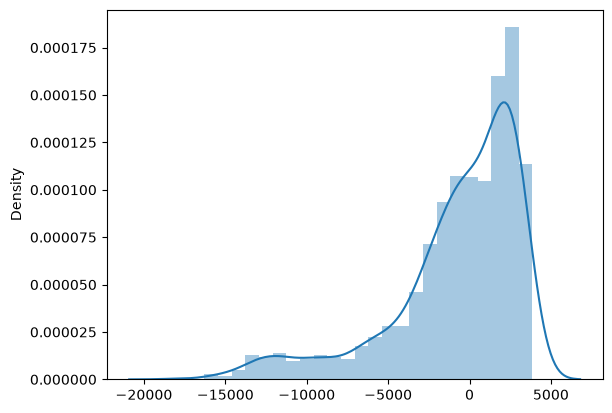

In [29]:
# if the prediction distribution are far from normal distribution
# then the model is not probably good enough
# distplot is deprecating in future pandas-version
# unfortunately, there's no exact alternative to do this plot at the moment
sns.distplot((y_test - test_predictions))
plt.show()
plt.close()

#### Try model in practice (with a new imaginary house)

In [30]:
# just to quickly check what support variables we should include
# in the tester_row -part below
X.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z'], dtype='str')

In [31]:
# print a few example houses so we can test with
# the tester row below
df.head(3)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,5,6,2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,4,6,3,59.8,61.0,326,3.89,3.84,2.31
2,0.23,2,6,5,56.9,65.0,327,4.05,4.07,2.31


In [32]:
# let's try with some new imaginary data
# this example uses the student performance index score dataset
# modify this as needed regarding your own dataset
tester_row = {
    'carat': 0.81, 
    'cut': 3, 
    'color': 4, 
    'clarity': 2, 
    'depth': 62.9, 
    'table': 56.9, 
    'x': 5.89, 
    'y': 5.96, 
    'z': 3.73
}

# convert to pandas-format
tester_row = pd.DataFrame([tester_row])

In [33]:
# get the prediction from the model and print out the result
result = model.predict(tester_row)[0]

print()
print(f"Estimated energy bill for this house:")
print(f"$ {round(float(result[0]), 2)}")
print("----------------")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

Estimated energy bill for this house:
$ 2588.87
----------------
